=== First 5 Rows of Training Data ===
      SEQN  RIAGENDR  PAQ605  BMXBMI  LBXGLU  DIQ010  LBXGLT  LBXIN age_group
0  73564.0       2.0     2.0    35.7   110.0     2.0   150.0  14.91     Adult
1  73568.0       2.0     2.0    20.3    89.0     2.0    80.0   3.85     Adult
2  73576.0       1.0     2.0    23.2    89.0     2.0    68.0   6.14     Adult
3  73577.0       1.0     2.0    28.9   104.0     NaN    84.0  16.15     Adult
4  73580.0       2.0     1.0    35.9   103.0     2.0    81.0  10.92     Adult

=== Training Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1966 entries, 0 to 1965
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SEQN       1954 non-null   float64
 1   RIAGENDR   1948 non-null   float64
 2   PAQ605     1953 non-null   float64
 3   BMXBMI     1948 non-null   float64
 4   LBXGLU     1953 non-null   float64
 5   DIQ010     1948 non-null   float64
 6   LBXGLT     1955 non-null   float64


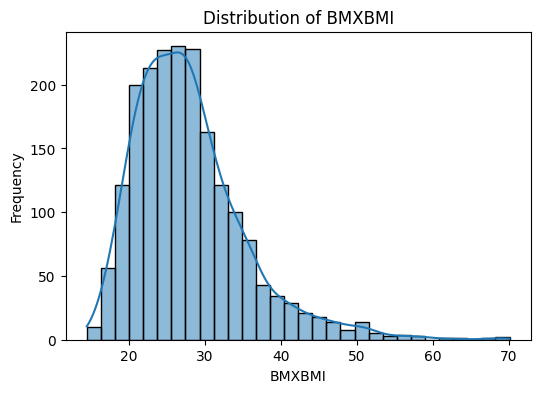

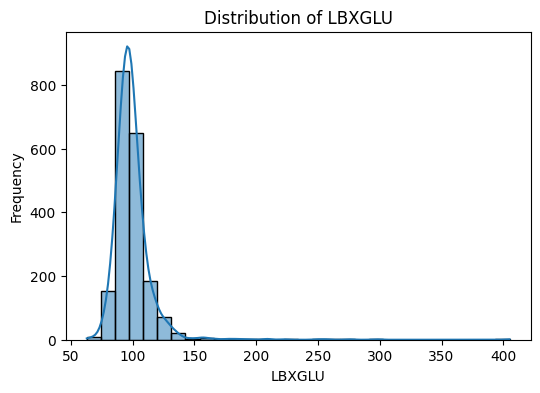

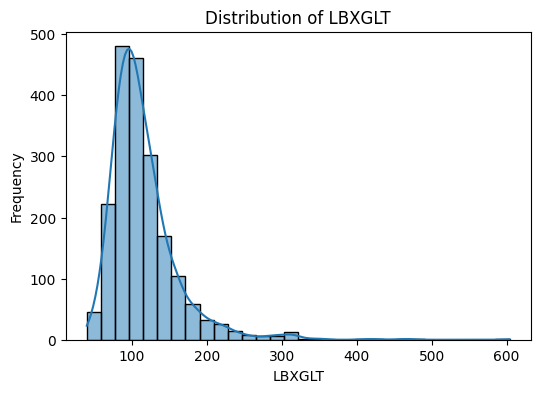

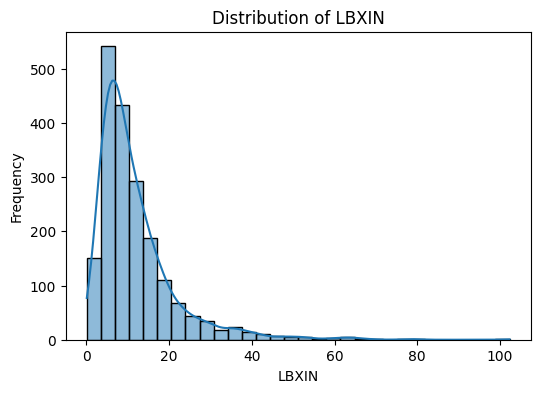


Missing target values BEFORE mapping: 14
Missing target values AFTER mapping: 14
Shape after dropping missing targets: (1952, 9)


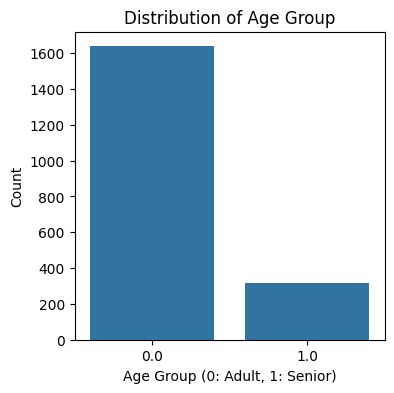

Best Parameters from GridSearch: {'model__C': 0.01, 'model__penalty': 'l2'}
Best Cross-Validation F1 Score: 0.4235832714198192

=== Validation Classification Report ===
              precision    recall  f1-score   support

         0.0       0.89      0.73      0.80       328
         1.0       0.27      0.52      0.35        63

    accuracy                           0.69       391
   macro avg       0.58      0.62      0.58       391
weighted avg       0.79      0.69      0.73       391

Validation F1 Score: 0.3548387096774194

Submission file 'submission.csv' created successfully!


In [1]:
# Full Code: EDA, Preprocessing, Modeling, Evaluation, and Submission

# Step 0: Import Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn modules for data splitting, modeling and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

# Step 1: Load the Data
train = pd.read_csv('Train_Data.csv')
test = pd.read_csv('Test_Data.csv')

# Step 2: Preliminary EDA on Training Data
print("=== First 5 Rows of Training Data ===")
print(train.head())

print("\n=== Training Data Info ===")
print(train.info())

print("\n=== Statistical Summary of Training Data ===")
print(train.describe())

# Check for missing values in every column in the training data
print("\n=== Missing Values in Training Data ===")
print(train.isnull().sum())

# Step 3: Investigate and Plot Distributions for Key Numeric Features
numeric_cols = ['BMXBMI', 'LBXGLU', 'LBXGLT', 'LBXIN']
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(train[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# Step 4: Check Target Column ("age_group") Before Mapping
print("\nMissing target values BEFORE mapping:", train['age_group'].isnull().sum())

# Step 5: Map the Target Variable
# Map 'Adult' to 0 and 'Senior' to 1; any unexpected values will become NaN.
train['age_group'] = train['age_group'].map({'Adult': 0, 'Senior': 1})
print("Missing target values AFTER mapping:", train['age_group'].isnull().sum())

# Step 6: Drop Rows with Missing Target Values (since they can't be used for training)
train = train.dropna(subset=['age_group'])
print("Shape after dropping missing targets:", train.shape)

# Step 7: Preprocess Features
# Remove identifier column 'SEQN'. This column does not provide any predictive power.
X = train.drop(columns=['age_group', 'SEQN'])
y = train['age_group']

# For test data, remove the same 'SEQN' column
X_test = test.drop(columns=['SEQN'])

# Step 8: Visualize the Target Distribution
plt.figure(figsize=(4, 4))
sns.countplot(x=y)
plt.title("Distribution of Age Group")
plt.xlabel("Age Group (0: Adult, 1: Senior)")
plt.ylabel("Count")
plt.show()

# Step 9: Build a Pipeline for Preprocessing and Modeling
# The steps include:
#   - Imputing missing values using the median,
#   - Scaling features,
#   - Logistic Regression classifier with class_weight='balanced' to handle class imbalance.
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
])

# Step 10: Hyperparameter Tuning via Grid Search with StratifiedKFold
param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l2']  # using l2 penalty; for l1, a different solver such as 'liblinear' is needed.
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(pipeline, param_grid, cv=skf, scoring='f1', n_jobs=-1)
grid_search.fit(X, y)

# Print the best parameters found and the associated cross-validation F1 score
print("Best Parameters from GridSearch:", grid_search.best_params_)
print("Best Cross-Validation F1 Score:", grid_search.best_score_)

# Step 11: Additional Evaluation Using a Train-Validation Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)
y_val_pred = best_model.predict(X_val)

print("\n=== Validation Classification Report ===")
print(classification_report(y_val, y_val_pred))
val_f1 = f1_score(y_val, y_val_pred)
print("Validation F1 Score:", val_f1)

# Step 12: Train the Final Model on the Full Training Data and Predict on the Test Data
best_model.fit(X, y)
test_predictions = best_model.predict(X_test)

# Step 13: Create the Submission File
# Create a DataFrame with one column "age_group". Each row must contain a prediction (0 or 1)
submission = pd.DataFrame({'age_group': test_predictions})
submission.to_csv('submission.csv', index=False)
print("\nSubmission file 'submission.csv' created successfully!")